# PlantVillage Leaf-Disease Classifier — Tiny GhostNet

A **very small** convolutional network for the PlantVillage dataset, built with
**Ghost Modules** (GhostNet, Han et al., 2020) instead of standard convolutions.

**Why Ghost Modules?** A regular conv layer that produces `out_channels` feature
maps needs `out_channels` full filters. A Ghost Module instead:
1. Uses a normal (but narrow) conv to generate a handful of "intrinsic" feature maps.
2. Generates the *rest* of the output cheaply, with depthwise convolutions applied
   to those intrinsic maps ("ghost" features).
3. Concatenates both parts together.

This roughly halves parameters/FLOPs vs. a normal conv of the same width, which is
why GhostNet-style models are smaller than MobileNetV2/ResNet at similar accuracy.

**What this notebook does**
1. Downloads the PlantVillage dataset via `kagglehub` (or point it at a local copy)
2. Loads it (`ImageFolder` layout: one folder per class)
3. Explores the class distribution and a few sample images
4. Defines `GhostModule` → `GhostBottleneck` → `GhostNetTiny` (~0.1–0.5M params)
5. Trains with augmentation, cosine LR schedule, label smoothing, AMP
6. Plots loss/accuracy curves
7. Evaluates with a confusion matrix + classification report
8. Runs inference on a single leaf image

> **Note:** the download cell uses `kagglehub` and needs Kaggle API credentials
> the first time it runs. If you already have the dataset locally, skip that
> cell and just set `DATA_DIR` manually in the config cell.


## 1. Setup

In [1]:
import os, json, math, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 2. Download the dataset (Kaggle)

Downloads the PlantVillage dataset via `kagglehub` and auto-detects the folder
that actually contains the per-class subfolders (Kaggle archives sometimes nest
it inside an extra directory or two).

Requires a Kaggle account/API access the first time it runs (kagglehub will
prompt you to authenticate if needed). If you already have the dataset on disk,
skip this cell and just set `DATA_DIR` manually in the next cell instead.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Path to dataset files:", path)

# The archive can nest the class folders a level or two deep (e.g. a "PlantVillage"
# or "color" subfolder). Auto-detect the directory that actually holds class
# subfolders full of images, so DATA_DIR below points at the right level.
import os

def find_image_folder_root(base_path):
    for dirpath, dirnames, filenames in os.walk(base_path):
        if not dirnames:
            continue
        # heuristic: a "class folder" root has subdirectories that themselves
        # contain image files directly
        sample_dir = os.path.join(dirpath, dirnames[0])
        sample_files = os.listdir(sample_dir)
        if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in sample_files):
            return dirpath
    return base_path

DATASET_ROOT = find_image_folder_root(path)
print("Detected class-folder root:", DATASET_ROOT)


Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Path to dataset files: /kaggle/input/plantvillage-dataset
Detected class-folder root: /kaggle/input/plantvillage-dataset/plantvillage dataset/segmented


In [3]:
# ---- CONFIG: edit these ----
DATA_DIR = DATASET_ROOT if "DATASET_ROOT" in dir() else "PlantVillage"  # folder containing one subfolder per class
IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 15
LR = 3e-3
WEIGHT_DECAY = 1e-4
WIDTH_MULT = 0.5               # GhostNet width multiplier: smaller -> fewer params
VAL_SPLIT = 0.2
LABEL_SMOOTHING = 0.1
OUTPUT_DIR = Path("./runs/ghost_plantvillage")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 3. Data loading & exploration

Assumes the standard PlantVillage / `ImageFolder` layout:

```
PlantVillage/
    Apple___Black_rot/
        img001.jpg
        ...
    Apple___healthy/
        ...
    Tomato___Late_blight/
        ...
```


In [4]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_ds = datasets.ImageFolder(DATA_DIR, transform=train_tf)
classes = full_ds.classes
num_classes = len(classes)
print(f"Found {num_classes} classes, {len(full_ds)} images total")

n_val = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
generator = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=generator)
# validation subset should use the non-augmented transform
val_ds.dataset = datasets.ImageFolder(DATA_DIR, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)

(OUTPUT_DIR / "classes.json").write_text(json.dumps(classes, indent=2))
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")


Found 38 classes, 54306 images total
Train: 43445  Val: 10861


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


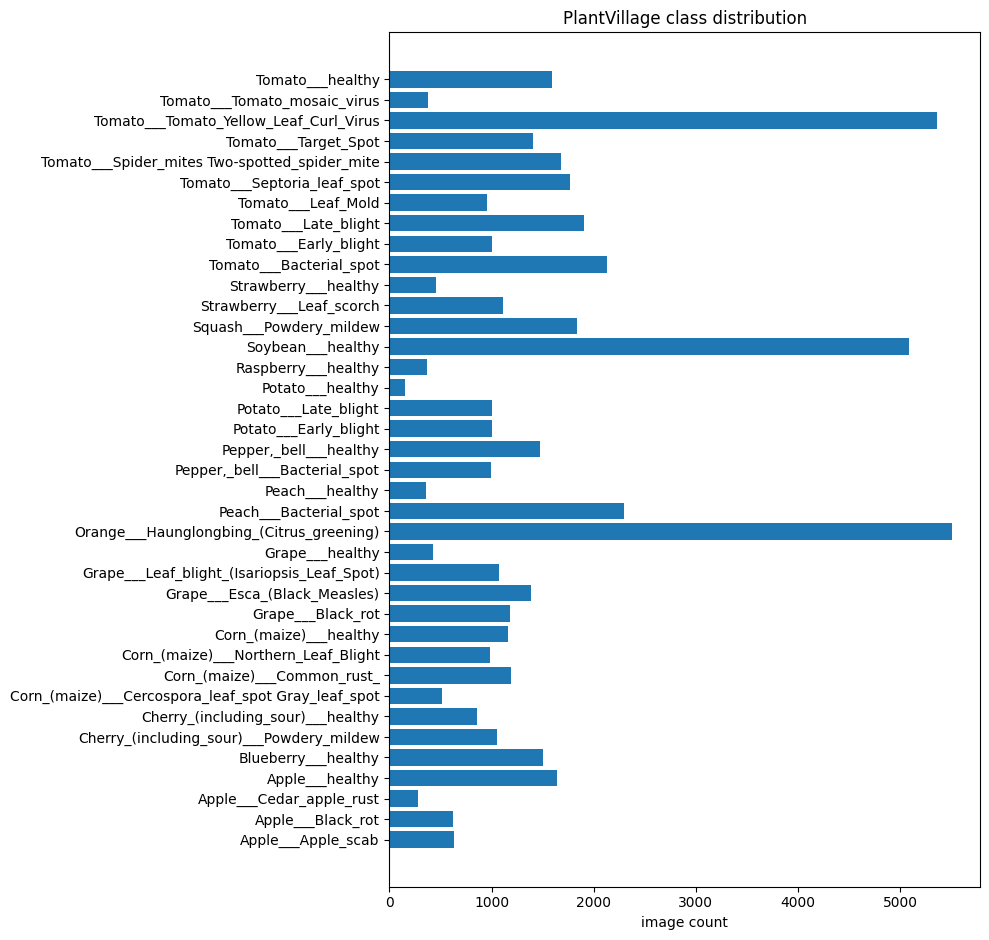

In [5]:
# Class distribution
counts = np.bincount([label for _, label in full_ds.samples], minlength=num_classes)
plt.figure(figsize=(10, max(4, num_classes * 0.25)))
plt.barh(classes, counts)
plt.xlabel("image count")
plt.title("PlantVillage class distribution")
plt.tight_layout()
plt.show()


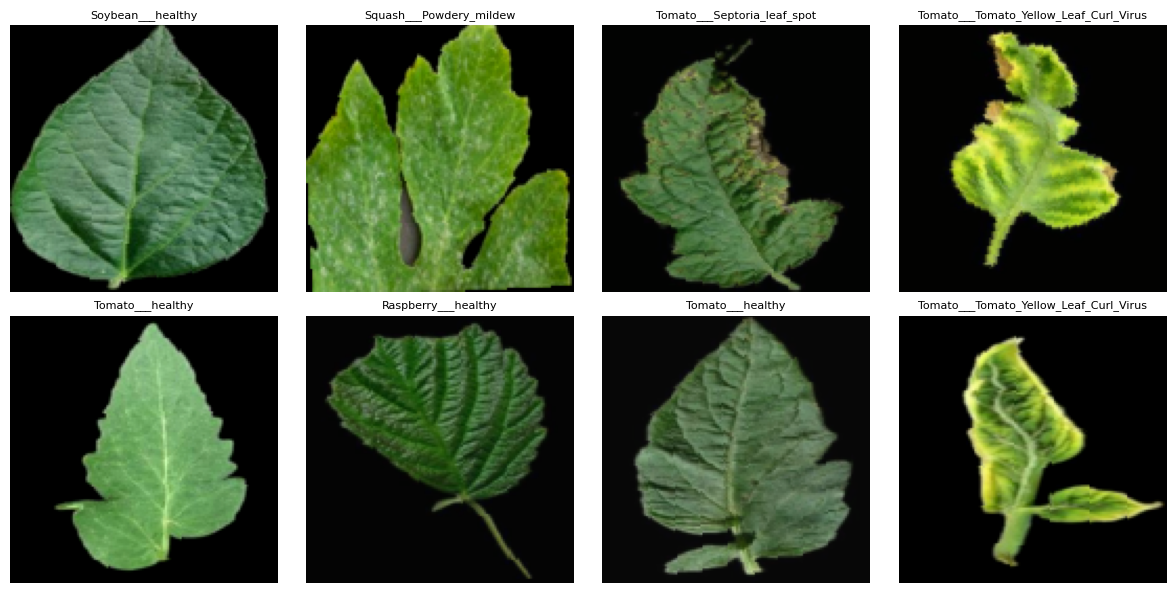

In [6]:
# A few sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225],
)
for ax in axes.flat:
    img, label = full_ds[np.random.randint(len(full_ds))]
    img = inv_normalize(img).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Model — Ghost Modules & GhostNetTiny

* `GhostModule`: cheap replacement for a standard conv layer.
* `GhostBottleneck`: inverted-residual block built from two Ghost Modules
  (mirrors MobileNetV2/GhostNet blocks), with an optional squeeze-excite
  channel-attention step.
* `GhostNetTiny`: a trimmed stack of bottlenecks (fewer stages/channels than
  the original GhostNet) sized for a small dataset like PlantVillage.


In [7]:
def _make_divisible(v, divisor=4, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


class SqueezeExcite(nn.Module):
    def __init__(self, channels, se_ratio=0.25):
        super().__init__()
        reduced = max(1, int(channels * se_ratio))
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(channels, reduced, 1, bias=True)
        self.act = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(reduced, channels, 1, bias=True)

    def forward(self, x):
        s = self.avg_pool(x)
        s = self.act(self.fc1(s))
        s = torch.sigmoid(self.fc2(s))
        return x * s


In [8]:
class GhostModule(nn.Module):
    """Generates `out_channels` maps from a small conv + cheap depthwise conv."""

    def __init__(self, in_channels, out_channels, kernel_size=1, ratio=2,
                 dw_size=3, stride=1, relu=True):
        super().__init__()
        self.out_channels = out_channels
        init_channels = math.ceil(out_channels / ratio)
        new_channels = init_channels * (ratio - 1)

        self.primary_conv = nn.Sequential(
            nn.Conv2d(in_channels, init_channels, kernel_size, stride,
                      kernel_size // 2, bias=False),
            nn.BatchNorm2d(init_channels),
            nn.ReLU(inplace=True) if relu else nn.Identity(),
        )
        self.cheap_operation = nn.Sequential(
            nn.Conv2d(init_channels, new_channels, dw_size, 1, dw_size // 2,
                      groups=init_channels, bias=False),
            nn.BatchNorm2d(new_channels),
            nn.ReLU(inplace=True) if relu else nn.Identity(),
        )

    def forward(self, x):
        x1 = self.primary_conv(x)
        x2 = self.cheap_operation(x1)
        out = torch.cat([x1, x2], dim=1)
        return out[:, :self.out_channels, :, :]


In [9]:
class GhostBottleneck(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 kernel_size=3, stride=1, use_se=False):
        super().__init__()
        assert stride in (1, 2)
        self.stride = stride
        self.ghost1 = GhostModule(in_channels, hidden_channels, relu=True)

        if stride == 2:
            self.dw = nn.Sequential(
                nn.Conv2d(hidden_channels, hidden_channels, kernel_size, stride,
                          kernel_size // 2, groups=hidden_channels, bias=False),
                nn.BatchNorm2d(hidden_channels),
            )
        else:
            self.dw = None

        self.se = SqueezeExcite(hidden_channels) if use_se else nn.Identity()
        self.ghost2 = GhostModule(hidden_channels, out_channels, relu=False)

        if in_channels == out_channels and stride == 1:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, in_channels, kernel_size, stride,
                          kernel_size // 2, groups=in_channels, bias=False),
                nn.BatchNorm2d(in_channels),
                nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        residual = x
        out = self.ghost1(x)
        if self.dw is not None:
            out = self.dw(out)
        out = self.se(out)
        out = self.ghost2(out)
        return out + self.shortcut(residual)


In [10]:
class GhostNetTiny(nn.Module):
    # (kernel_size, hidden_ch, out_ch, use_se, stride)
    CFG = [
        (3, 16, 16, False, 1),
        (3, 48, 24, False, 2),
        (3, 72, 24, False, 1),
        (5, 72, 40, True, 2),
        (5, 120, 40, True, 1),
        (3, 240, 80, False, 2),
        (3, 200, 80, False, 1),
        (3, 184, 96, True, 1),
        (5, 480, 96, True, 1),
    ]

    def __init__(self, num_classes=38, width_mult=0.5, in_channels=3, dropout=0.2):
        super().__init__()
        stem_ch = _make_divisible(16 * width_mult)
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stem_ch, 3, 2, 1, bias=False),
            nn.BatchNorm2d(stem_ch),
            nn.ReLU(inplace=True),
        )

        blocks = []
        in_ch = stem_ch
        for k, hidden_ch, out_ch, use_se, stride in self.CFG:
            hidden_ch = _make_divisible(hidden_ch * width_mult)
            out_ch = _make_divisible(out_ch * width_mult)
            blocks.append(GhostBottleneck(in_ch, hidden_ch, out_ch, k, stride, use_se))
            in_ch = out_ch
        self.blocks = nn.Sequential(*blocks)

        final_ch = _make_divisible(max(320 * width_mult, 128))
        self.head_conv = nn.Sequential(
            nn.Conv2d(in_ch, final_ch, 1, 1, 0, bias=False),
            nn.BatchNorm2d(final_ch),
            nn.ReLU(inplace=True),
        )
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(final_ch, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.head_conv(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [11]:
model = GhostNetTiny(num_classes=num_classes, width_mult=WIDTH_MULT).to(device)
n_params = count_parameters(model)
print(f"Model parameters: {n_params:,} ({n_params/1e6:.3f} M)")
print(f"For comparison: MobileNetV2 ~3.4M, ResNet18 ~11.2M, ResNet50 ~25.6M")


Model parameters: 89,235 (0.089 M)
For comparison: MobileNetV2 ~3.4M, ResNet18 ~11.2M, ResNet50 ~25.6M


## 5. Training loop

In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        running_loss += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, running_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return running_loss / total, running_correct / total


/tmp/ipykernel_1294/299681995.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


In [13]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    dt = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} acc {val_acc:.4f} | {dt:.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pt")

torch.save(model.state_dict(), OUTPUT_DIR / "last_model.pt")
(OUTPUT_DIR / "history.json").write_text(json.dumps(history, indent=2))
print(f"Best val accuracy: {best_val_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1/15 | train_loss 2.0756 acc 0.5151 | val_loss 1.5348 acc 0.6922 | 176.7s
Epoch   2/15 | train_loss 1.4268 acc 0.7438 | val_loss 1.2370 acc 0.8053 | 136.2s
Epoch   3/15 | train_loss 1.2521 acc 0.8072 | val_loss 1.2912 acc 0.7791 | 137.5s
Epoch   4/15 | train_loss 1.1468 acc 0.8463 | val_loss 1.0167 acc 0.8909 | 140.2s
Epoch   5/15 | train_loss 1.0774 acc 0.8718 | val_loss 1.0155 acc 0.8825 | 138.7s
Epoch   6/15 | train_loss 1.0297 acc 0.8901 | val_loss 1.0099 acc 0.8834 | 139.1s
Epoch   7/15 | train_loss 0.9883 acc 0.9033 | val_loss 0.9469 acc 0.9123 | 137.6s
Epoch   8/15 | train_loss 0.9543 acc 0.9144 | val_loss 0.8921 acc 0.9350 | 138.5s
Epoch   9/15 | train_loss 0.9262 acc 0.9242 | val_loss 0.8524 acc 0.9437 | 136.6s
Epoch  10/15 | train_loss 0.9024 acc 0.9322 | val_loss 0.8516 acc 0.9459 | 137.8s
Epoch  11/15 | train_loss 0.8845 acc 0.9390 | val_loss 0.8148 acc 0.9591 | 137.6s
Epoch  12/15 | train_loss 0.8685 acc 0.9448 | val_loss 0.8109 acc 0.9591 | 135.9s
Epoch  13/15 | t

## 6. Training curves

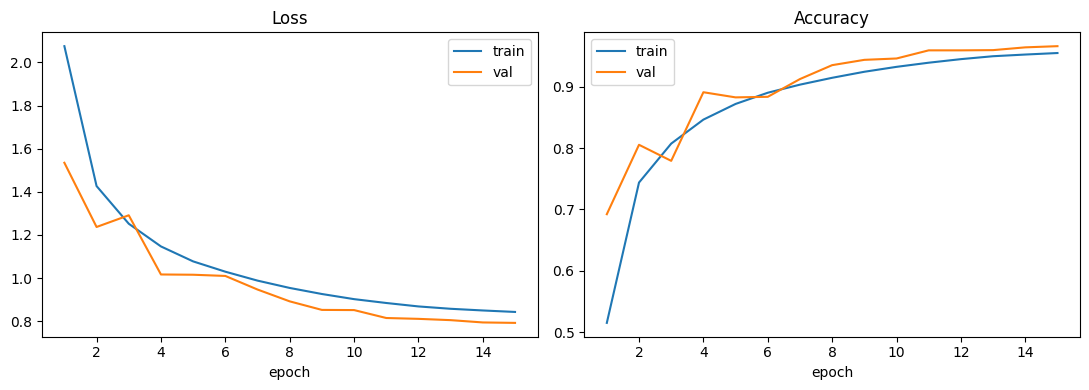

In [14]:
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "training_curves.png", dpi=150)
plt.show()


## 7. Evaluation — confusion matrix & classification report

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


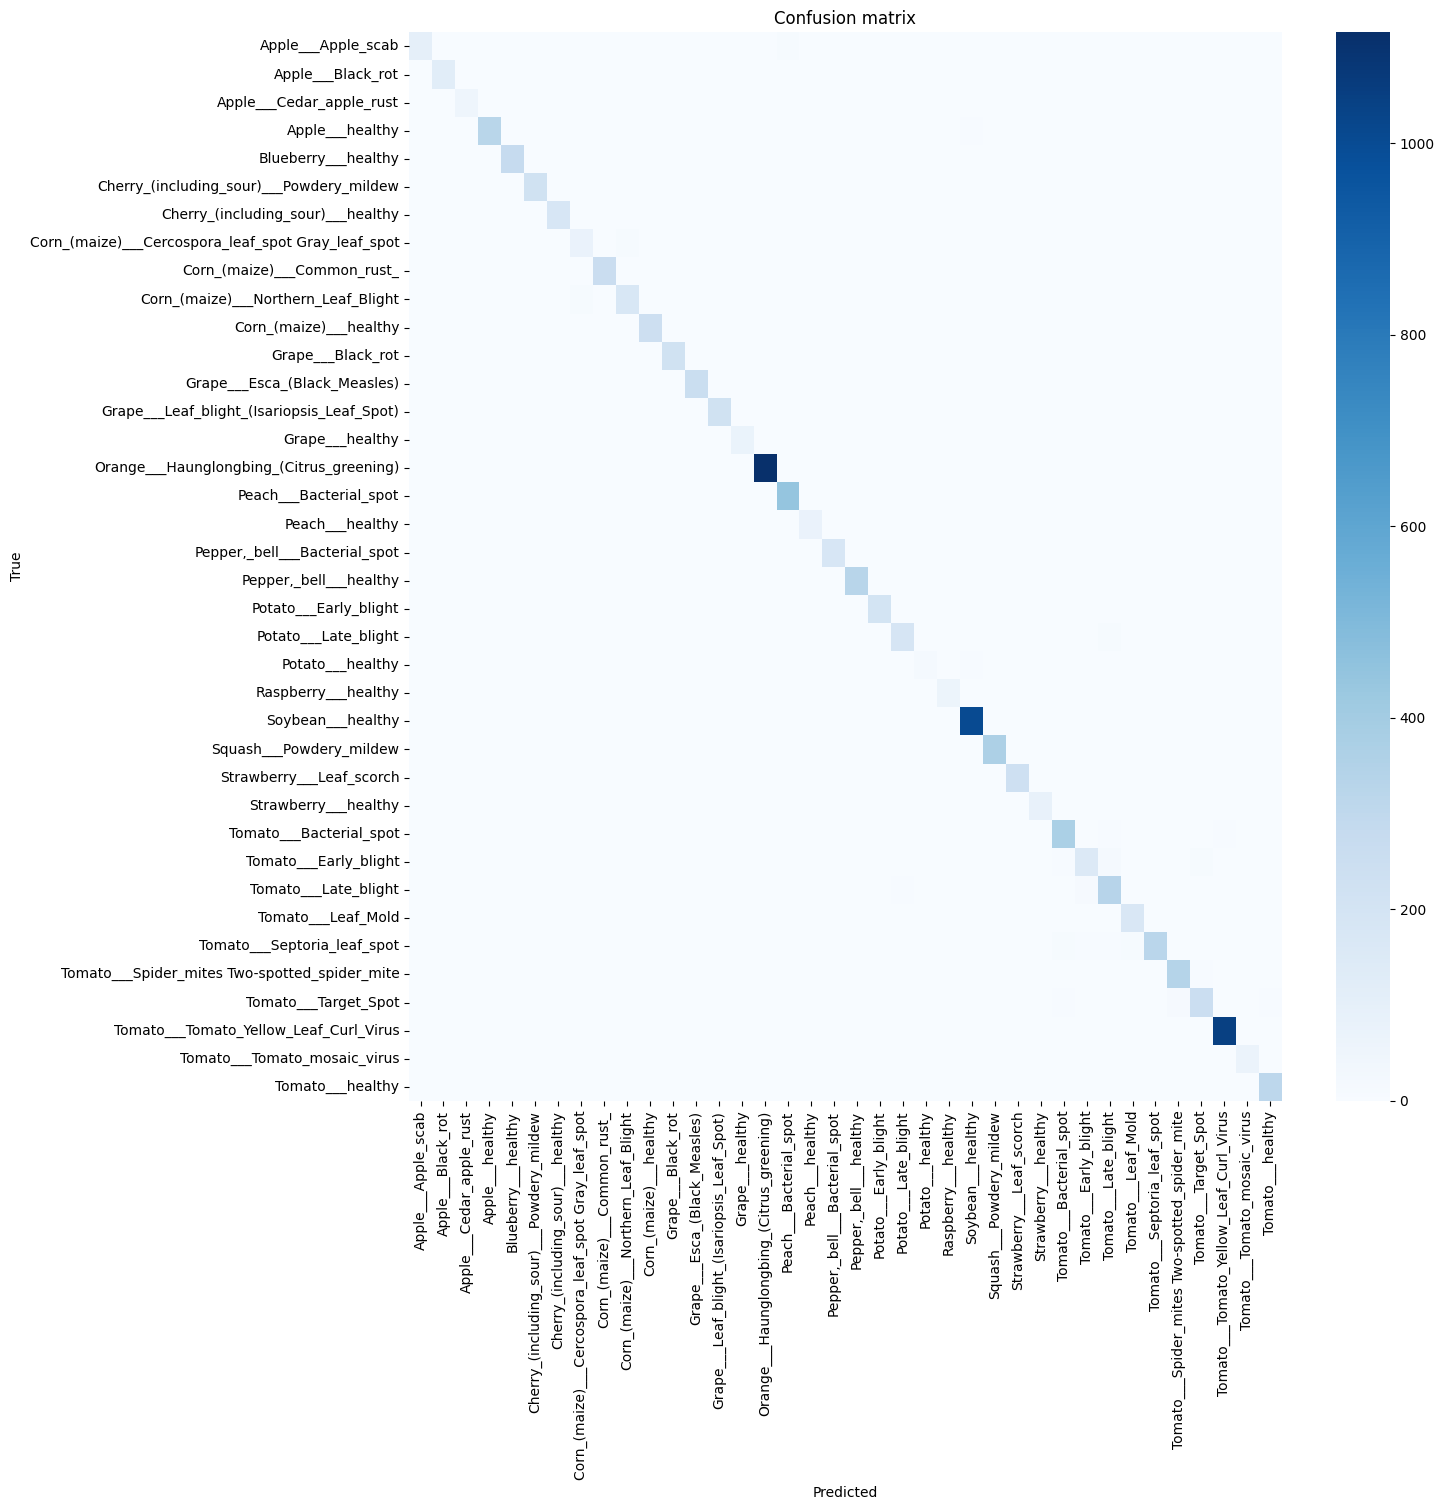

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.84      0.90       123
                                 Apple___Black_rot       0.98      0.97      0.98       127
                          Apple___Cedar_apple_rust       0.98      0.91      0.95        57
                                   Apple___healthy       0.96      0.98      0.97       333
                               Blueberry___healthy       0.98      0.99      0.98       287
          Cherry_(including_sour)___Powdery_mildew       0.99      0.99      0.99       225
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       185
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.88      0.85      0.86        91
                       Corn_(maize)___Common_rust_       0.98      0.99      0.98       262
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.92      0.

In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns  # optional, falls back to matplotlib if unavailable

model.load_state_dict(torch.load(OUTPUT_DIR / "best_model.pt", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
plt.figure(figsize=(max(6, num_classes * 0.4), max(5, num_classes * 0.4)))
try:
    sns.heatmap(cm, annot=num_classes <= 15, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
except Exception:
    plt.imshow(cm, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion matrix")
plt.xticks(rotation=90); plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, labels=list(range(num_classes)),
                             target_names=classes, zero_division=0))


## 8. Inference on a single image

In [16]:
def predict_image(model, image_path, img_size, classes, device):
    from PIL import Image
    tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    img = Image.open(image_path).convert("RGB")
    tensor = tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1)[0]
    top_prob, top_idx = probs.max(0)
    return classes[top_idx.item()], top_prob.item(), img


# Example — replace with a real image path
# label, conf, img = predict_image(model, "path/to/leaf.jpg", IMG_SIZE, classes, device)
# plt.imshow(img); plt.axis("off"); plt.title(f"{label} ({conf:.2%})"); plt.show()


## Summary

* `GhostNetTiny` at `width_mult=0.5` has well under **0.5M parameters** — roughly
  10–50x smaller than MobileNetV2 / ResNet18, while still using a modern
  inverted-residual + squeeze-excite design.
* Increase `WIDTH_MULT` (e.g. 0.75, 1.0) or `IMG_SIZE` if you have more data/compute
  and want higher accuracy at the cost of a larger model.
* All artifacts (`best_model.pt`, `classes.json`, `history.json`,
  `training_curves.png`) are saved to `OUTPUT_DIR` for reuse — this matches the
  layout expected by the companion `ghost_plantvillage.py` script's `--predict` mode.
